In [20]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
df=pd.read_csv('train.csv')

# EDA

In [24]:
df.shape

(8693, 14)

In [25]:
df[df.duplicated()]
#no duplicate values

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported


In [26]:
df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [27]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [29]:
df.columns

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported'],
      dtype='object')

In [30]:
df.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [31]:
#handling null values
df['RoomService'].fillna(0,inplace=True)
df['FoodCourt'].fillna(0,inplace=True)
df['ShoppingMall'].fillna(0,inplace=True)
df['Spa'].fillna(0,inplace=True)
df['VRDeck'].fillna(0,inplace=True)
df['CryoSleep'].fillna(False,inplace=True)
df['VIP'].fillna(False,inplace=True)

In [32]:
from sklearn.preprocessing import LabelEncoder
le1=LabelEncoder()
df['CryoSleep']=le1.fit_transform(df['CryoSleep'])
le2=LabelEncoder()
df['VIP']=le2.fit_transform(df['VIP'])

In [33]:
print(df['HomePlanet'].value_counts())


HomePlanet
Earth     4602
Europa    2131
Mars      1759
Name: count, dtype: int64


In [34]:
print(df['Destination'].value_counts())

Destination
TRAPPIST-1e      5915
55 Cancri e      1800
PSO J318.5-22     796
Name: count, dtype: int64


In [35]:
print(df['Cabin'].value_counts())

Cabin
G/734/S     8
G/109/P     7
B/201/P     7
G/1368/P    7
G/981/S     7
           ..
G/556/P     1
E/231/S     1
G/545/S     1
G/543/S     1
F/947/P     1
Name: count, Length: 6560, dtype: int64


In [36]:
#drop name
df.drop('Name',inplace=True,axis=1)

<Axes: xlabel='RoomService'>

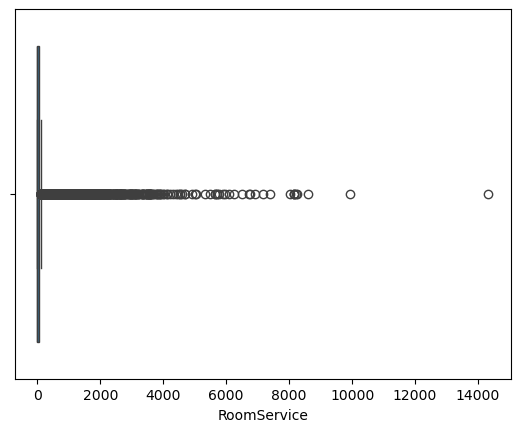

In [37]:
sns.boxplot(x=df['RoomService'])
#plots to check which type of imputation should be used

<Axes: xlabel='Age'>

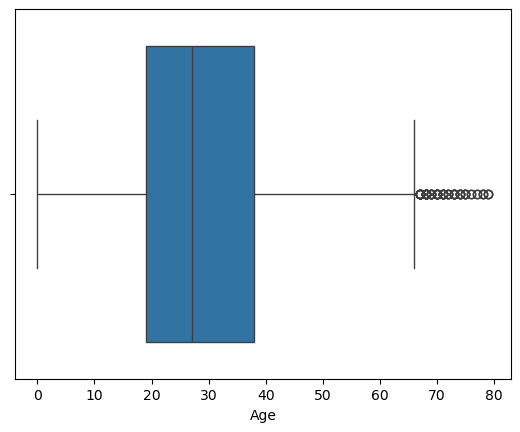

In [38]:
sns.boxplot(x=df['Age'])
#plots to check which type of imputation should be used

Text(0, 0.5, 'Frequency')

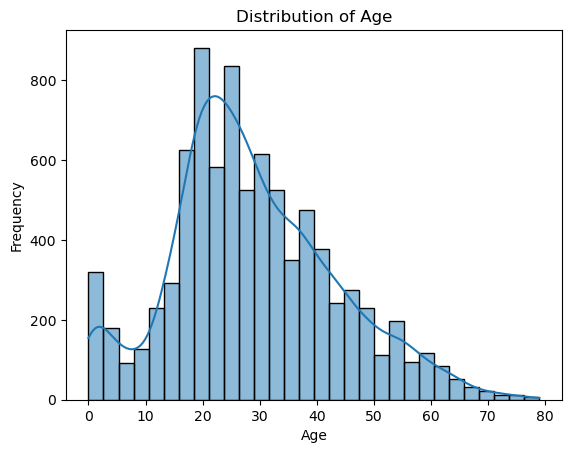

In [39]:
#histogram
sns.histplot(data=df, x='Age', kde=True, bins=30)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')


In [40]:
#since outliers using median imputation
df['Age'].fillna(df['Age'].median(), inplace=True)

In [41]:
df[['deck','num','side']] = df['Cabin'].str.split('/',expand=True)
#expand=True to store the values in each column as strings and not as lists

In [42]:
df.drop('Cabin',axis=1,inplace=True)

In [43]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,deck,num,side
0,0001_01,Europa,0,TRAPPIST-1e,39.0,0,0.0,0.0,0.0,0.0,0.0,False,B,0,P
1,0002_01,Earth,0,TRAPPIST-1e,24.0,0,109.0,9.0,25.0,549.0,44.0,True,F,0,S
2,0003_01,Europa,0,TRAPPIST-1e,58.0,1,43.0,3576.0,0.0,6715.0,49.0,False,A,0,S
3,0003_02,Europa,0,TRAPPIST-1e,33.0,0,0.0,1283.0,371.0,3329.0,193.0,False,A,0,S
4,0004_01,Earth,0,TRAPPIST-1e,16.0,0,303.0,70.0,151.0,565.0,2.0,True,F,1,S


In [44]:
print(df['deck'].value_counts())
print(df['num'].value_counts())
print(df['side'].value_counts())

deck
F    2794
G    2559
E     876
B     779
C     747
D     478
A     256
T       5
Name: count, dtype: int64
num
82      28
86      22
19      22
56      21
176     21
        ..
1644     1
1515     1
1639     1
1277     1
1894     1
Name: count, Length: 1817, dtype: int64
side
S    4288
P    4206
Name: count, dtype: int64


In [45]:
df['side'].fillna('N',inplace=True)
df['deck'].fillna('N',inplace=True)
df['HomePlanet'].fillna('N',inplace=True)
df['Destination'].fillna('N',inplace=True)

In [46]:
df['num'] = df['num'].astype(float)
df['num'].fillna(df['num'].median(),inplace=True)

In [47]:
df.isnull().sum()

PassengerId     0
HomePlanet      0
CryoSleep       0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Transported     0
deck            0
num             0
side            0
dtype: int64

In [48]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,deck,num,side
0,0001_01,Europa,0,TRAPPIST-1e,39.0,0,0.0,0.0,0.0,0.0,0.0,False,B,0.0,P
1,0002_01,Earth,0,TRAPPIST-1e,24.0,0,109.0,9.0,25.0,549.0,44.0,True,F,0.0,S
2,0003_01,Europa,0,TRAPPIST-1e,58.0,1,43.0,3576.0,0.0,6715.0,49.0,False,A,0.0,S
3,0003_02,Europa,0,TRAPPIST-1e,33.0,0,0.0,1283.0,371.0,3329.0,193.0,False,A,0.0,S
4,0004_01,Earth,0,TRAPPIST-1e,16.0,0,303.0,70.0,151.0,565.0,2.0,True,F,1.0,S


In [49]:
df.isnull().sum()

PassengerId     0
HomePlanet      0
CryoSleep       0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Transported     0
deck            0
num             0
side            0
dtype: int64

In [50]:
#one hot encoding
cat=['deck', 'side', 'HomePlanet','Destination']
num=['Age','VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
df=pd.get_dummies(df, columns=['deck', 'side', 'HomePlanet','Destination'], drop_first=True)

<Axes: xlabel='Age', ylabel='Count'>

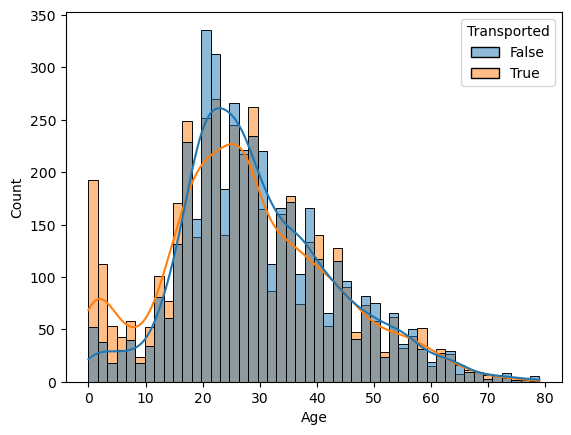

In [51]:
sns.histplot(data=df, x='Age', kde=True, hue='Transported')

In [52]:
df['Amount']=df['VIP']+df['RoomService']+df["FoodCourt"]+df['ShoppingMall']+df['Spa']+df["VRDeck"]

<Axes: >

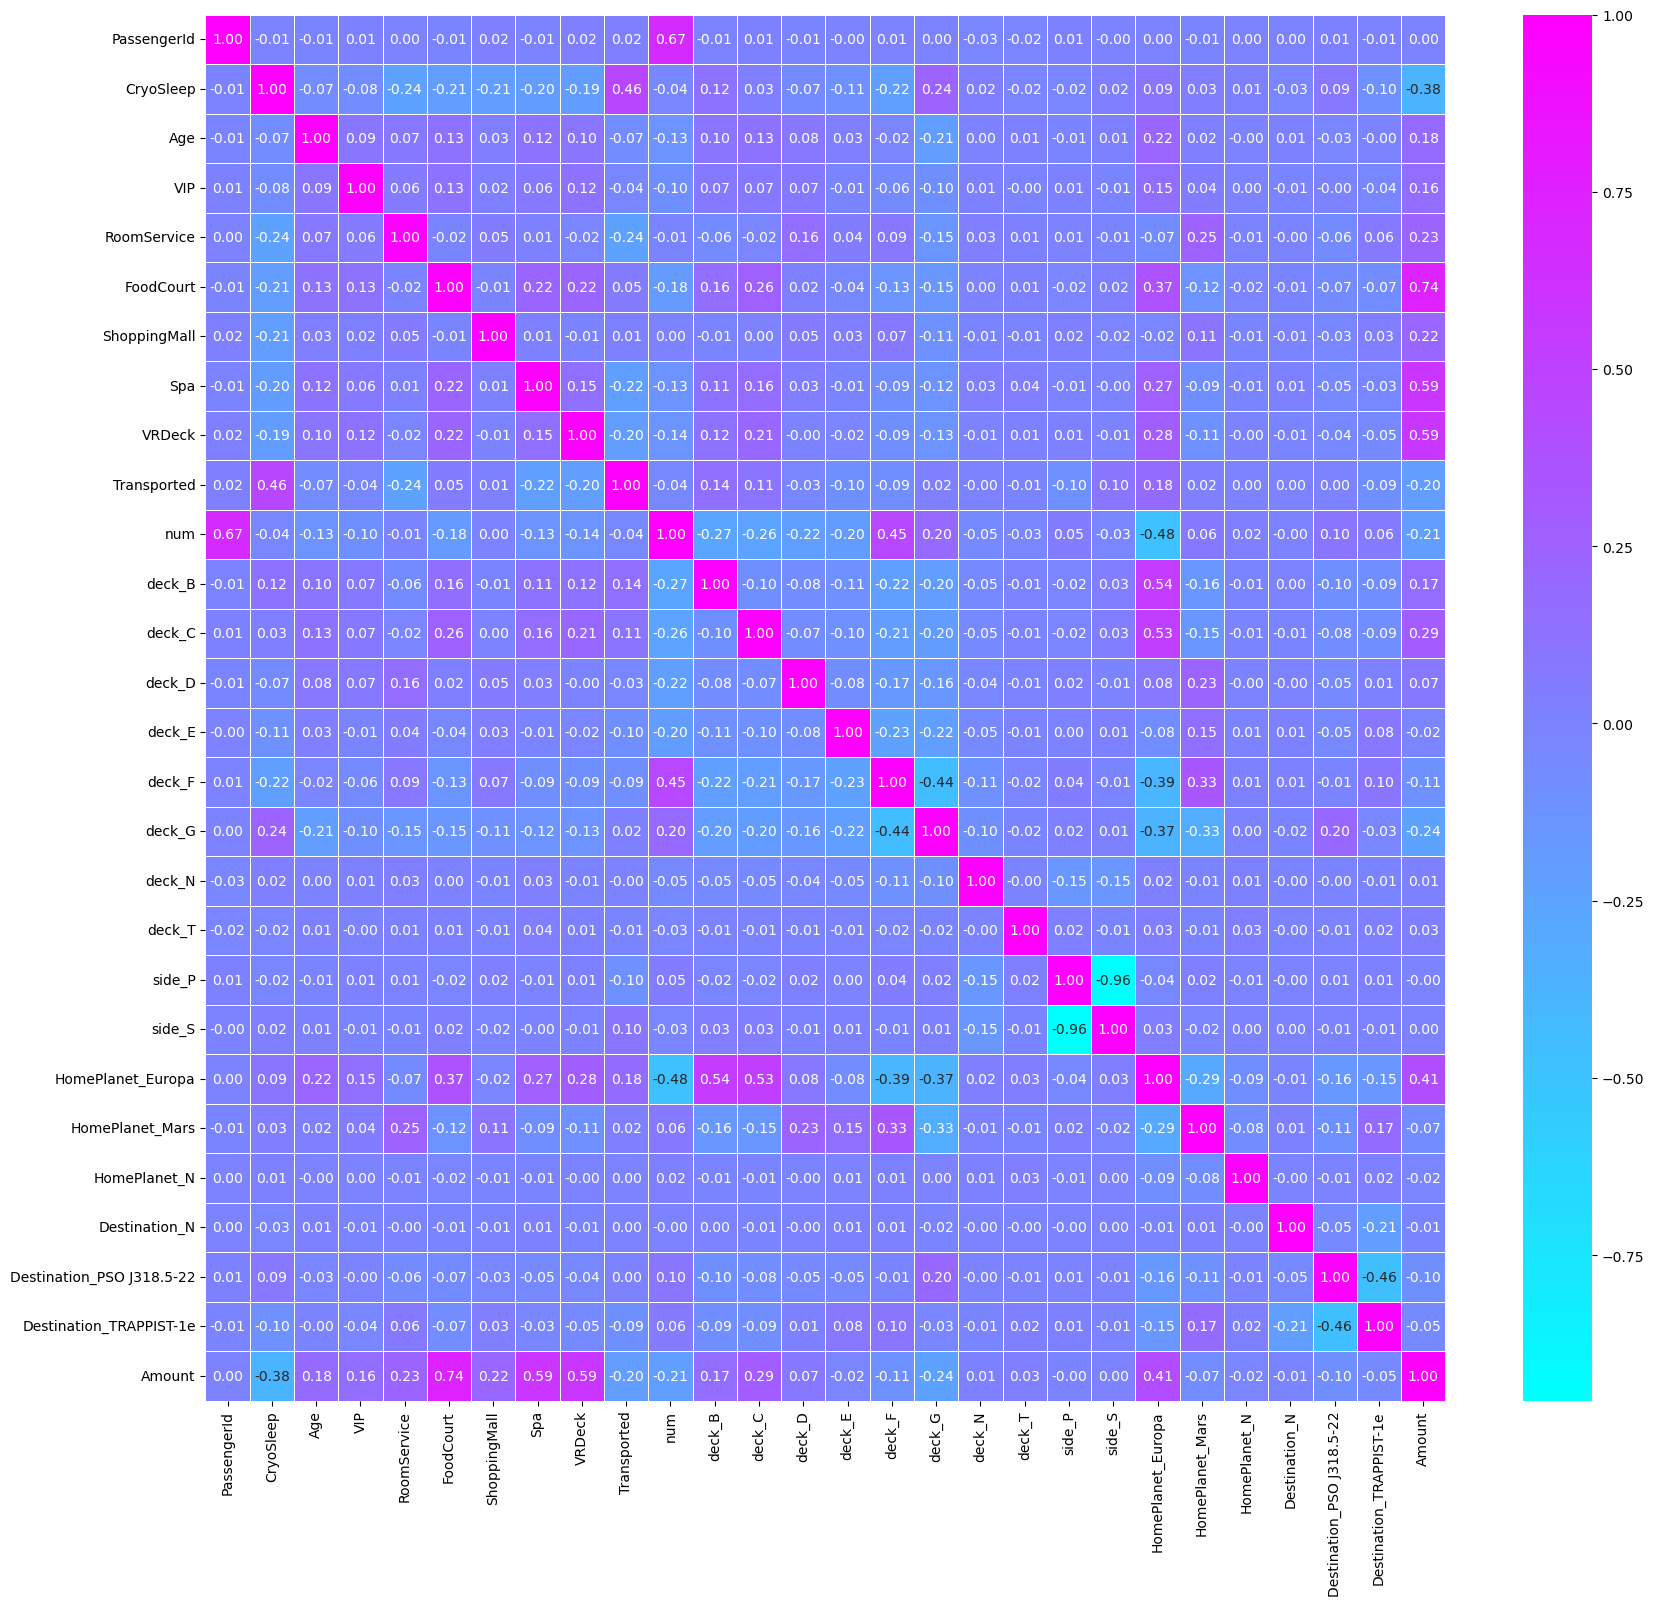

In [53]:
plt.figure(figsize=(20, 18))
sns.heatmap(df.corr(), annot=True,cmap='cool', fmt='.2f', linewidths=0.5)

# Application of Different Models

In [55]:
#features
x=df.drop('Transported',axis=1)
#target
y=df['Transported']


In [56]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=123)

In [57]:
from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()

#to handle outliers

In [58]:
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

## Logistic Regression

In [60]:
from sklearn.linear_model import LogisticRegression

In [61]:
lr=LogisticRegression()

In [62]:
from sklearn.model_selection import GridSearchCV

In [63]:
penalty=['l1', 'l2', 'elasticnet']
c_values=[100,10,1.0,0.1,0.01]
solver=['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
para=dict(penalty=penalty,C=c_values,solver=solver)

In [64]:
from sklearn.model_selection import StratifiedKFold
cv=StratifiedKFold()

In [65]:
grid=GridSearchCV(estimator=lr, param_grid=para,
scoring='accuracy', cv=cv,error_score=np.nan)

In [66]:
grid.fit(x_train,y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(),
             param_grid={'C': [100, 10, 1.0, 0.1, 0.01],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga']},
             scoring='accuracy')

In [67]:
grid.best_params_

{'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}

In [68]:
grid.best_score_

0.7935002508417421

In [69]:
y_pred=grid.predict(x_test)

In [70]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


In [71]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:", classification_report(y_test, y_pred))

Accuracy: 0.8039102932719954
Confusion Matrix:
 [[636 215]
 [126 762]]
Classification Report:               precision    recall  f1-score   support

       False       0.83      0.75      0.79       851
        True       0.78      0.86      0.82       888

    accuracy                           0.80      1739
   macro avg       0.81      0.80      0.80      1739
weighted avg       0.81      0.80      0.80      1739



In [72]:
acc_lr=0.8039102932719954

## SVM

In [74]:
from sklearn.svm import LinearSVC

In [75]:
svc=LinearSVC()

In [76]:
svc.fit(x_train,y_train)

LinearSVC()

In [77]:
y_pred=svc.predict(x_test)

In [78]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7826336975273146
Confusion Matrix:
 [[665 186]
 [192 696]]
Classification Report:
               precision    recall  f1-score   support

       False       0.78      0.78      0.78       851
        True       0.79      0.78      0.79       888

    accuracy                           0.78      1739
   macro avg       0.78      0.78      0.78      1739
weighted avg       0.78      0.78      0.78      1739



In [79]:
acc_svc=0.7757331799884991

## Naive Baye's

In [81]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(x_train, y_train)
# gaussian nb because of a lot of numerical features

GaussianNB()

In [82]:
y_pred=nb.predict(x_test)

In [83]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7182288671650374
Confusion Matrix:
 [[415 436]
 [ 54 834]]
Classification Report:
               precision    recall  f1-score   support

       False       0.88      0.49      0.63       851
        True       0.66      0.94      0.77       888

    accuracy                           0.72      1739
   macro avg       0.77      0.71      0.70      1739
weighted avg       0.77      0.72      0.70      1739



In [84]:
acc_nb=0.7182288671650374

## KNN

In [86]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()

In [87]:
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [88]:
y_pred=knn.predict(x_test)

In [89]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7929844738355377
Confusion Matrix:
 [[676 175]
 [185 703]]
Classification Report:
               precision    recall  f1-score   support

       False       0.79      0.79      0.79       851
        True       0.80      0.79      0.80       888

    accuracy                           0.79      1739
   macro avg       0.79      0.79      0.79      1739
weighted avg       0.79      0.79      0.79      1739



In [90]:
acc_knn=0.7929844738355377

## Decision Tree Classifier

In [92]:
from sklearn.tree import DecisionTreeClassifier
dtc= DecisionTreeClassifier()

In [93]:
dtc.fit(x_train,y_train)

DecisionTreeClassifier()

In [94]:
y_pred=dtc.predict(x_test)

In [95]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7642323174238068
Confusion Matrix:
 [[636 215]
 [195 693]]
Classification Report:
               precision    recall  f1-score   support

       False       0.77      0.75      0.76       851
        True       0.76      0.78      0.77       888

    accuracy                           0.76      1739
   macro avg       0.76      0.76      0.76      1739
weighted avg       0.76      0.76      0.76      1739



In [96]:
acc_dtc=0.7688326624496837

## Random Forest Classifier

In [98]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier()

In [101]:
rfc.fit(x_train,y_train)

RandomForestClassifier()

In [102]:
y_pred=rfc.predict(x_test)

In [103]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8182863714778609
Confusion Matrix:
 [[725 126]
 [190 698]]
Classification Report:
               precision    recall  f1-score   support

       False       0.79      0.85      0.82       851
        True       0.85      0.79      0.82       888

    accuracy                           0.82      1739
   macro avg       0.82      0.82      0.82      1739
weighted avg       0.82      0.82      0.82      1739



In [104]:
acc_rfc=0.816561242093157

## Gradient Boosting Classifier

In [106]:
from sklearn.ensemble import GradientBoostingClassifier
gbc= GradientBoostingClassifier()

In [107]:
gbc.fit(x_train,y_train)

GradientBoostingClassifier()

In [108]:
y_pred=gbc.predict(x_test)

In [109]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.816561242093157
Confusion Matrix:
 [[667 184]
 [135 753]]
Classification Report:
               precision    recall  f1-score   support

       False       0.83      0.78      0.81       851
        True       0.80      0.85      0.83       888

    accuracy                           0.82      1739
   macro avg       0.82      0.82      0.82      1739
weighted avg       0.82      0.82      0.82      1739



In [110]:
acc_gbc=0.816561242093157

## AdaBoost Classifier

In [112]:
from sklearn.ensemble import AdaBoostClassifier
ada=AdaBoostClassifier(n_estimators=100)

In [113]:
ada.fit(x_train,y_train)

AdaBoostClassifier(n_estimators=100)

In [114]:
y_pred=ada.predict(x_test)

In [115]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8079355951696378
Confusion Matrix:
 [[645 206]
 [128 760]]
Classification Report:
               precision    recall  f1-score   support

       False       0.83      0.76      0.79       851
        True       0.79      0.86      0.82       888

    accuracy                           0.81      1739
   macro avg       0.81      0.81      0.81      1739
weighted avg       0.81      0.81      0.81      1739



In [116]:
acc_ada=0.8079355951696378

## XG Boost Classifier

In [118]:
!pip install xgboost


In [119]:
from xgboost import XGBClassifier
xgb=XGBClassifier(n_estimators=100)

In [120]:
xgb.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [121]:
y_pred=xgb.predict(x_test)

In [122]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8205865439907993
Confusion Matrix:
 [[696 155]
 [157 731]]
Classification Report:
               precision    recall  f1-score   support

       False       0.82      0.82      0.82       851
        True       0.83      0.82      0.82       888

    accuracy                           0.82      1739
   macro avg       0.82      0.82      0.82      1739
weighted avg       0.82      0.82      0.82      1739



# Hyperparameter Tuning

### Random Forest Classifier

In [125]:
params = {"max_depth": [5, 8, 15, None, 10],
             "max_features": [5, 7, "auto", 8],
             "min_samples_split": [2, 8, 15, 20],
             "n_estimators": [100, 200, 500, 1000]}

In [126]:
from sklearn.model_selection import RandomizedSearchCV
random=RandomizedSearchCV(RandomForestClassifier(),params,cv=3)

In [127]:
random.fit(x_train,y_train)

RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(),
                   param_distributions={'max_depth': [5, 8, 15, None, 10],
                                        'max_features': [5, 7, 'auto', 8],
                                        'min_samples_split': [2, 8, 15, 20],
                                        'n_estimators': [100, 200, 500, 1000]})

In [128]:
y_pred=random.predict(x_test)

In [129]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8148361127084531
Confusion Matrix:
 [[683 168]
 [154 734]]
Classification Report:
               precision    recall  f1-score   support

       False       0.82      0.80      0.81       851
        True       0.81      0.83      0.82       888

    accuracy                           0.81      1739
   macro avg       0.81      0.81      0.81      1739
weighted avg       0.81      0.81      0.81      1739



In [130]:
acc_rfc=0.81943645773433

### XGBoost

In [132]:
params={"learning_rate": [0.1, 0.01],
        "max_depth": [5, 8, 12, 20, 30],
        "n_estimators": [100, 200, 300],
        "colsample_bytree": [0.5, 0.8, 1, 0.3, 0.4]}

In [191]:
xgb_hpt=RandomizedSearchCV(XGBClassifier(),params,cv=5,scoring='accuracy')

In [193]:
xgb_hpt.fit(x_train,y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                           max_delta_step=None, max_depth=None,
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   param_distributions={'colsample_bytree': [0.5, 0.8, 1, 0.3,
                                                             0.4],
                                        'learning_rate': [0.1, 0.01],
                                        'max_depth': [5, 8, 12, 20, 30],
                                        'n_estimators': [100, 200, 300]},
                   scoring='accuracy')

In [194]:
y_pred=xgb_hpt.predict(x_test)

In [195]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8280621046578494
Confusion Matrix:
 [[698 153]
 [146 742]]
Classification Report:
               precision    recall  f1-score   support

       False       0.83      0.82      0.82       851
        True       0.83      0.84      0.83       888

    accuracy                           0.83      1739
   macro avg       0.83      0.83      0.83      1739
weighted avg       0.83      0.83      0.83      1739



In [223]:
acc_xgb=0.8280621046578494

# Evaluation of the models

In [225]:
models=['Logistic Regression', 'LinearSVC' , 'Naive Bayes', 'KNN', 'Random Forest', 'Decision Tree', 'Gradient Boosting','AdaBoost','XG Boost']
accuracy=[acc_lr , acc_svc , acc_nb , acc_knn , acc_rfc , acc_dtc , acc_gbc , acc_ada , acc_xgb]

In [199]:
len(accuracy)==len(models)

True

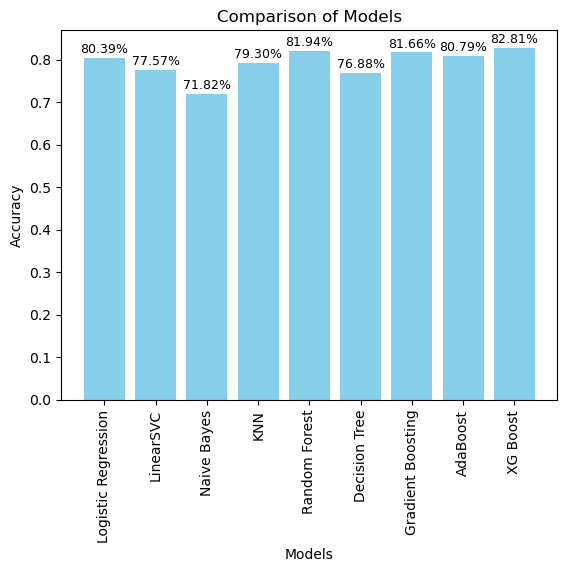

In [227]:

plt.xlabel('Models')
plt.xticks(rotation=90)
plt.ylabel('Accuracy')
plt.title('Comparison of Models')
bars = plt.bar(models, accuracy,color="skyblue")
for bar in bars:
    yval = bar.get_height()
    percent = yval * 100
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.005, f'{percent:.2f}%', 
             ha='center', va='bottom', fontsize=9)


#### XG Boost has the best performance

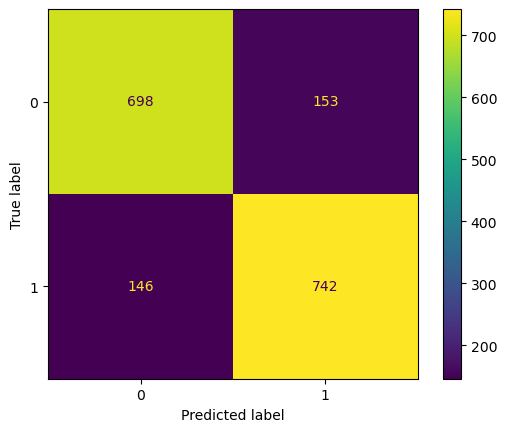

In [229]:
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()

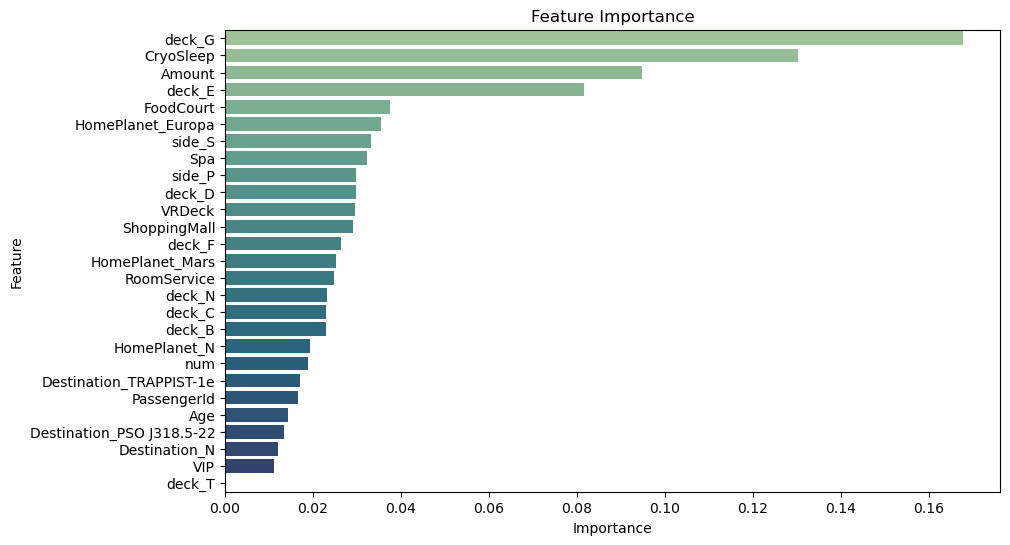

In [231]:
model=xgb
importances = model.feature_importances_
features = x.columns
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette = 'crest')
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# Applying the model on test data

In [289]:
df_test=pd.read_csv("test.csv")
dfc_test=pd.read_csv("test.csv")

In [291]:
df_test['RoomService'].fillna(0,inplace=True)
df_test['FoodCourt'].fillna(0,inplace=True)
df_test['ShoppingMall'].fillna(0,inplace=True)
df_test['Spa'].fillna(0,inplace=True)
df_test['VRDeck'].fillna(0,inplace=True)
df_test['CryoSleep'].fillna(False,inplace=True)
df_test['VIP'].fillna(False,inplace=True)

In [293]:
from sklearn.preprocessing import LabelEncoder
le1=LabelEncoder()
df_test['CryoSleep']=le1.fit_transform(df_test['CryoSleep'])
le2=LabelEncoder()
df_test['VIP']=le2.fit_transform(df_test['VIP'])

In [295]:
df_test.drop('Name',inplace=True,axis=1)

In [297]:
df_test['Age'].fillna(df_test['Age'].median(), inplace=True)

df_test[['deck','num','side']] = df_test['Cabin'].str.split('/', expand=True)
df_test.drop('Cabin', axis=1, inplace=True)

df_test['side'].fillna('N', inplace=True)
df_test['deck'].fillna('N', inplace=True)
df_test['HomePlanet'].fillna('N', inplace=True)
df_test['Destination'].fillna('N', inplace=True)

df_test['num'] = df_test['num'].astype(float)
df_test['num'].fillna(df_test['num'].median(), inplace=True)

df_test = pd.get_dummies(df_test, columns=['deck', 'side', 'HomePlanet', 'Destination'], drop_first=True)

df_test['Amount'] = df_test['VIP'] + df_test['RoomService'] + df_test['FoodCourt'] + df_test['ShoppingMall'] + df_test['Spa'] + df_test['VRDeck']


In [299]:
df_test.head()


,PassengerId,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,num,...,deck_T,side_P,side_S,HomePlanet_Europa,HomePlanet_Mars,HomePlanet_N,Destination_N,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,Amount
0,0013_01,1,27.0,0,0.0,0.0,0.0,0.0,0.0,3.0,...,False,False,True,False,False,False,False,False,True,0.0
1,0018_01,0,19.0,0,0.0,9.0,0.0,2823.0,0.0,4.0,...,False,False,True,False,False,False,False,False,True,2832.0
2,0019_01,1,31.0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,True,True,False,False,False,False,False,0.0
3,0021_01,0,38.0,0,0.0,6652.0,0.0,181.0,585.0,1.0,...,False,False,True,True,False,False,False,False,True,7418.0
4,0023_01,0,20.0,0,10.0,0.0,635.0,0.0,0.0,5.0,...,False,False,True,False,False,False,False,False,True,645.0


In [301]:
df_test = df_test.reindex(columns=x.columns, fill_value=0)
df_test = scaler.transform(df_test)

In [303]:
y_pred_final = xgb_hpt.predict(df_test)

In [305]:
submission = pd.DataFrame({'PassengerId': dfc_test['PassengerId'],'Transported': y_pred_final.astype(bool)})

In [307]:
submission.head()

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


In [309]:
submission.to_csv("submission.csv", index=False)